<a href="https://colab.research.google.com/github/BoufenoucheBouchra/Introduction-Apprentissage-Automatique/blob/main/TP1_M2bioinfo_IAA_ManipulationDonnees.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP1: Manipulation des données sous PYTHON
## Auteurs : Mathieu Serrurier, Jérôme Farinas, Ronan Sicre

Utilisation du package `pandas`


## Objectifs du TP

Un préalable à l'utilisation d'algorithmes d'apprentissage statistique
est le chargement, la mise en forme et l'analyse de base de données. Le
package `pandas` de `Python` met à dispostion un ensemble de structures
de données et d'outils très pratiques permettant cela. L'objectif de ce
TP est de se familiariser avec ces stuctures et outils.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Monter son google drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pwd
!ls

/content
drive  sample_data


In [ ]:
%cd drive/MyDrive/
!ls

/content/drive/MyDrive
'1081-REUMANN-A (1).jpg'
 1081-REUMANN-A.jpg
 1641158549382_1641158546136_convention_70571_BOUCHRA_BOUFENOUCHE_CK.pdf
'20220104_101847 (1).mp4'
 20220104_101847.mp4
 20220104_104420.jpg
 20220104_115142.mp4
 20220105_102643.jpg
 20220110_100557.jpg
 20220110_103053.jpg
 20220110_122903.jpg
 20220117_123630.jpg
'20220320_105935 (1).jpg'
'20220320_105935 (2).jpg'
'20220320_105935 (3).jpg'
 20220320_105935.jpg
'20220320_110019 (1).jpg'
'20220320_110019 (2).jpg'
'20220320_110019 (3).jpg'
 20220320_110019.jpg
'20220320_114507 (1).jpg'
 20220320_114507.jpg
 20220320_114611.jpg
 20230404_132519.jpg
 20230404_132528.jpg
'22-04-05 12-47-57 BIO666 - Fluorescence-bouchralex (1).csv'
'22-04-05 12-47-57 BIO666 - Fluorescence-bouchralex (1).gsheet'
'22-04-05 12-47-57 BIO666 - Fluorescence-bouchralex.csv'
'22-04-05 12-47-57 BIO666 - Fluorescence-bouchralex.gsheet'
'22205097_2022-23_7L326A_sess1_sem1_N3 Bio. cellul. physio. (1) (2).pdf'
'22205097_2022-23_7L326A_sess1_sem2_N3 Bio

## Liste des fonctions que nous utiliserons

Ci-dessous $s$ représente une liste et $t$ un tableau à 2 dimensions

| Fonction | Description |
|:---------|:-------------|
|`s = Series(data, index)`|Creation d'une liste indexée |
|`t = DataFrame(data, index, columns)`|Creation d'un tableau à 2 dimensions|
|`s.index` or `t.index`|Renvoie l'index de `s` ou de `t`|
|`s.values`|Renvoie la liste des valeurs de `s`|
|`t = read_csv('fichier.csv')`|Charge une base contenue dans `fichier.csv` dans `t`|
|`random.permutation(x)`|Si `x` est entier, crée une séquence aléatoire d'entiers entre 1 et `x`|
|`random.choice(a,size,replace)`|Génère un échantillon aléatoire d'éléments de `a`|avec (`replace=True`) ou sans remise (`replace`=False)|
|`t.drop(label,axis)`|Crée un DataFrame à partir de `t` dont les lignes (axis=0)|ou les colonnes (axis=1) spécifiées dans `label` ont été supprimées|
|`t.duplicated()`|Renvoie la liste des doublons de lignes|
|`t.replace(value1,value2)`|Remplace `value1` par `value2` dans `t`|
|`t.fillna(value)`|Remplace les valeurs manquantes `nan` par `value`|
|`t.dropna(axis)`|Supprime les lignes (axis=0) ou les colonnes (axis=1)|avec valeurs manquantes|
|`t.describe()`|Affiche des statistiques sur `t`|
|`t.mean(axis)`|Renvoie la valeur moyenne selon l’axe précisé (0 ou 1)|
|`t.min(axis)`|Renvoie la valeur mini selon l’axe précisé (0 ou 1)|
|`t.max(axis)`|Renvoie la valeur maxi selon l’axe précisé (0 ou 1)|
|`t.value_counts()`|Renvoie le nombre de valeurs unique de `t`|
|`s.hist()`|Affiche l’histogramme des valeurs de `s`|
|`t.crosstab(column1,column2)`|Calcule et affiche le tableau de contingence des 2 variables de `t`|

## 1 - La structure de données `DataFrame`

La deuxième structure proposée par `pandas` permet de gérer des tableaux
de données. C’est donc un tableau à 2 dimensions avec des index de
lignes et colonnes. L’index de colonnes correspond aux noms des
variables de la base de données et l’index des lignes correspond aux
différents individus de la population que représente la base.

(a) Créer un objet de type `DataFrame` contenant les données suivantes:

|  _Animal_ | **Aquatic** | **Tail** |
|:---------:|:-----------:|:--------:|
|**crab**   |     True    |  False   |
|**deer**   |     False   |  True    |
|**hamster**|     False   |  True    |
|**dolphin**|     True    |  False   |

In [ ]:
dataframe =pd.DataFrame({"Animal":["crab","deer","hamster","dolphin"],
                         "Aquatic":["True","False","False","True"],
                         "Tail":["False","True","True","False"]})

(b) Faire afficher à l’écran la liste des index de cette base avec la fonction `t.index`


In [ ]:
print(dataframe.to_string(index=False))
print(list(dataframe.index))

 Animal Aquatic  Tail
   crab    True False
   deer   False  True
hamster   False  True
dolphin    True False
[0, 1, 2, 3]


(c) Faire afficher à l’écran la liste des colonnes (variables) de la base avec la fonction `t.columns`

In [ ]:
print(list(dataframe.columns))

['Animal', 'Aquatic', 'Tail']


(d) Faire afficher à l’écran les valeurs des variables de la ligne `deer`

In [ ]:
print(dataframe[dataframe["Animal"]== "deer"].values)

[['deer' 'False' 'True']]


(e) Créer une `DataFrame` qui contiendra uniquement les animaux “aquatiques”

In [ ]:
df_aqua=dataframe[dataframe["Aquatic"]== "True"]
print(df_aqua.to_string(index=False))

 Animal Aquatic  Tail
   crab    True False
dolphin    True False


## 2 - Chargement de données à partir d’un fichier `.csv`

(a) Charger dans une `DataFrame` la base de données `zoo` à partir du
    fichier `.csv` disponible sur Moodle

In [ ]:
zoo=pd.read_csv("/content/drive/MyDrive/AA/zoo.csv")
print(zoo.head())
zoo

     animal   hair  feathers   eggs   milk  airborne  aquatic  predator  \
0  aardvark   True     False  False   True     False    False      True   
1  antelope   True     False  False   True     False    False     False   
2      bass  False     False   True  False     False     True      True   
3      bear   True     False  False   True     False    False      True   
4      boar   True     False  False   True     False    False      True   

   toothed  backbone  breathes  venomous   fins  legs   tail  domestic  \
0     True      True      True     False  False     4  False     False   
1     True      True      True     False  False     4   True     False   
2     True      True     False     False   True     0   True     False   
3     True      True      True     False  False     4  False     False   
4     True      True      True     False  False     4   True     False   

   catsize    type  
0     True  mammal  
1     True  mammal  
2    False    fish  
3     True  mammal  

,animal,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type
0,aardvark,True,False,False,True,False,False,True,True,True,True,False,False,4,False,False,True,mammal
1,antelope,True,False,False,True,False,False,False,True,True,True,False,False,4,True,False,True,mammal
2,bass,False,False,True,False,False,True,True,True,True,False,False,True,0,True,False,False,fish
3,bear,True,False,False,True,False,False,True,True,True,True,False,False,4,False,False,True,mammal
4,boar,True,False,False,True,False,False,True,True,True,True,False,False,4,True,False,True,mammal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,wallaby,True,False,False,True,False,False,False,True,True,True,False,False,2,True,False,True,mammal
97,wasp,True,False,True,False,True,False,False,False,False,True,True,False,6,False,False,False,insect
98,wolf,True,False,False,True,False,False,True,True,True,True,False,False,4,True,False,True,mammal
99,worm,False,False,True,False,False,False,False,False,False,True,False,False,0,False,False,False,invertebrate


(b) Faire afficher la liste des variables de la base

In [ ]:
print(list(zoo.columns))

['animal', 'hair', 'feathers', 'eggs', 'milk', 'airborne', 'aquatic', 'predator', 'toothed', 'backbone', 'breathes', 'venomous', 'fins', 'legs', 'tail', 'domestic', 'catsize', 'type']


## 3 - Sélection de données

(a) Créer une fonction `Melange(t)` qui prendra en paramètre une DataFrame `t` et renverra la DataFrame dont les lignes ont été mélangées aléatoirement. Tester sur la base `zoo`.

In [ ]:
def Melange(t):
    res=t.sample(frac=1)
    return res
zoo_mel=Melange(zoo)
print(list(zoo_mel.columns))
print(zoo_mel.head())
print("----------------")
print(zoo_mel[0:10])

['animal', 'hair', 'feathers', 'eggs', 'milk', 'airborne', 'aquatic', 'predator', 'toothed', 'backbone', 'breathes', 'venomous', 'fins', 'legs', 'tail', 'domestic', 'catsize', 'type']
      animal   hair  feathers   eggs   milk  airborne  aquatic  predator  \
88   termite  False     False   True  False     False    False     False   
21      duck  False      True   True  False      True     True     False   
0   aardvark   True     False  False   True     False    False      True   
99      worm  False     False   True  False     False    False     False   
45      lion   True     False  False   True     False    False      True   

    toothed  backbone  breathes  venomous   fins  legs   tail  domestic  \
88    False     False      True     False  False     6  False     False   
21    False      True      True     False  False     2   True     False   
0      True      True      True     False  False     4  False     False   
99    False     False      True     False  False     0  Fal

(b) Créer un script `Tirage1(t,n)` qui prendra en paramètre une DataFrame `t` et un entier `n` et renverra une DataFrame contenant $n$ lignes de `t` tirées aléatoirement (avec remise). Tester sur la base `zoo`.

In [ ]:
def Tirage1(t,n):
    t_tir=t.sample(n=n,replace=True) #Tire n lignes aléatoires de la DataFrame t. --#replace=True → permet de tirer plusieurs fois la même ligne.
    return t_tir
print("Tirage avec remise :")
print(Tirage1(zoo,4))

Tirage avec remise :
      animal   hair  feathers   eggs   milk  airborne  aquatic  predator  \
59  pheasant  False      True   True  False      True    False     False   
46   lobster  False     False   True  False     False     True      True   
1   antelope   True     False  False   True     False    False     False   
2       bass  False     False   True  False     False     True      True   

    toothed  backbone  breathes  venomous   fins  legs   tail  domestic  \
59    False      True      True     False  False     2   True     False   
46    False     False     False     False  False     6  False     False   
1      True      True      True     False  False     4   True     False   
2      True      True     False     False   True     0   True     False   

    catsize          type  
59    False          bird  
46    False  invertebrate  
1      True        mammal  
2     False          fish  


(c) Créer une variante `Tirage2(t,n)` avec tirage sans remise.

In [ ]:
def Tirage2(t,n):
    t_tir=t.sample(n=n,replace=False) #False pour tirage sans remise
    return t_tir
print("Tirage sans remise :")
print(Tirage2(zoo,4))

Tirage sans remise :
     animal   hair  feathers   eggs   milk  airborne  aquatic  predator  \
7      carp  False     False   True  False     False     True     False   
35  hamster   True     False  False   True     False    False     False   
6      calf   True     False  False   True     False    False     False   
33     gull  False      True   True  False      True     True      True   

    toothed  backbone  breathes  venomous   fins  legs  tail  domestic  \
7      True      True     False     False   True     0  True      True   
35     True      True      True     False  False     4  True      True   
6      True      True      True     False  False     4  True      True   
33    False      True      True     False  False     2  True     False   

    catsize    type  
7     False    fish  
35    False  mammal  
6      True  mammal  
33    False    bird  


(d) Vérifier dans les 2 cas avec la fonction `t.duplicated` l’existence ou non de doublons de lignes(remise ou non).

In [ ]:
print(Tirage1(zoo,10).duplicated()) # renvoie True/False pour chaque ligne

print(Tirage1(zoo,10).duplicated().any()) ## Vérifier s'il y a au moins un doublon --> True si au moins un doublon
print(Tirage2(zoo,10).duplicated().any())

64    False
40    False
2     False
96    False
11    False
29    False
59    False
46    False
81    False
42    False
dtype: bool
True
False


### Suppression et transformation de données

(a) Charger dans une `DataFrame` la base de données `titanic2` à partir du fichier `.csv` disponible sur Moodle:

_Avant de répondre aux questions suivantes, dupliquer votre DataFrame dans une autre DataFrame pour en avoir 2 versions._

In [ ]:
titanic2 = pd.read_csv("/content/drive/MyDrive/AA/titanic2.csv")
titanic_copy=titanic2.copy()
print(titanic2.head())
print("---------------------")
print(titanic_copy.head())

   Unnamed: 0      class     age  sex survived
0           1  1st class  adults  man      yes
1           2  1st class  adults  man      yes
2           3  1st class  adults  man      yes
3           4  1st class  adults  man      yes
4           5  1st class  adults  man      yes
---------------------
   Unnamed: 0      class     age  sex survived
0           1  1st class  adults  man      yes
1           2  1st class  adults  man      yes
2           3  1st class  adults  man      yes
3           4  1st class  adults  man      yes
4           5  1st class  adults  man      yes


(b) Afficher les lignes dont la valeur de la variable `class` est `unknown` et supprimer une des lignes avec la fonction `t.drop(index)`. Faire la même chose avec la variable `age`.

In [ ]:
C=titanic2[titanic2['class']=="unknown"]
A=titanic2[titanic2['age']=="unknown"]
print(C)
print("le nombre de ligne est :",len(C))
Cc=C.drop(C.index[0])
print(Cc)
print(A)
print("le nombre de ligne est :",len(A))
Aa=A.drop(A.index[0])
print(Aa)

      Unnamed: 0    class     age  sex survived
22            23  unknown  adults  man      yes
119          120  unknown  adults  man       no
166          167  unknown  adults  man       no
442          443  unknown  adults  man       no
657          658  unknown  adults  man      yes
1036        1037  unknown  adults  man       no
1271        1272  unknown   child  man       no
le nombre de ligne est : 7
      Unnamed: 0    class     age  sex survived
119          120  unknown  adults  man       no
166          167  unknown  adults  man       no
442          443  unknown  adults  man       no
657          658  unknown  adults  man      yes
1036        1037  unknown  adults  man       no
1271        1272  unknown   child  man       no
      Unnamed: 0      class      age    sex survived
121          122  1st class  unknown    man       no
341          342  2nd class  unknown    man       no
594          595  2nd class  unknown    man      yes
739          740  3rd class  unknown    m

(c) Pour éviter de le faire sur l’ensemble des lignes une à une, on utilisera plutôt la gestion de données manquantes de `pandas`. Pour cela, à l’aide de la fonction `replace`, on remplacera l’ensemble des variables `unknown` par la valeur `nan` reconnue par `pandas`.

In [ ]:
titanic2.replace("unknown", np.nan, inplace=True)
print(titanic2.head())
print("\nNombre de valeurs manquantes par colonne :")
print(titanic2.isna().sum())


   Unnamed: 0      class     age  sex survived
0           1  1st class  adults  man      yes
1           2  1st class  adults  man      yes
2           3  1st class  adults  man      yes
3           4  1st class  adults  man      yes
4           5  1st class  adults  man      yes

Nombre de valeurs manquantes par colonne :
Unnamed: 0    0
class         7
age           5
sex           0
survived      0
dtype: int64


(d) Supprimer les lignes contenant les valeurs manquantes avec la fonction `dropna(axis=0)`

In [ ]:
r=titanic2[titanic2.isna().any(axis=1)]
print(r)
print(len(r))
tit=titanic2.dropna(axis=0)
print(tit)
print(tit[tit.isna().any (axis=1)])

      Unnamed: 0      class     age    sex survived
22            23        NaN  adults    man      yes
119          120        NaN  adults    man       no
121          122  1st class     NaN    man       no
166          167        NaN  adults    man       no
341          342  2nd class     NaN    man       no
442          443        NaN  adults    man       no
594          595  2nd class     NaN    man      yes
657          658        NaN  adults    man      yes
739          740  3rd class     NaN    man       no
1036        1037        NaN  adults    man       no
1117        1118  3rd class     NaN  women      yes
1271        1272        NaN   child    man       no
12
      Unnamed: 0      class     age    sex survived
0              1  1st class  adults    man      yes
1              2  1st class  adults    man      yes
2              3  1st class  adults    man      yes
3              4  1st class  adults    man      yes
4              5  1st class  adults    man      yes
...      

(e) Avec la deuxième version de la DataFrame, utiliser la fonction `fillna` pour remplacer les valeurs manquantes “nan” par leur valeur la plus fréquente.

In [ ]:
for col in titanic_copy.columns:
  val_frq=titanic_copy[col].mode()[0] #mode() renvoie une Series contenant le mode pour récuperer la premiere valeur il faut mettre 0 entre []
  titanic_copy[col].fillna(val_frq,inplace=True)
print(titanic_copy.isna().sum())

Unnamed: 0    0
class         0
age           0
sex           0
survived      0
dtype: int64


/tmp/ipython-input-2135504190.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic_copy[col].fillna(val_frq,inplace=True)


### Statistiques descriptives élémentaires

(a) Charger dans une `DataFrame` la base de données `cancer` à partir du fichier `.csv` disponible sur Moodle.

In [ ]:
cancer=pd.read_csv("/content/drive/MyDrive/AA/cancer.csv")
#print(cancer)
cancer
#print(len(list(cancer.columns)))
#print(list(cancer.columns))


,Clump_Thickness,Cell_Size_Uniformity,Cell_Shape_Uniformity,Marginal_Adhesion,Single_Epi_Cell_Size,Bare_Nuclei,Bland_Chromatin,Normal_Nucleoli,Mitoses,Class
0,5,1,1,1,2,1.0,3,1,1,benign
1,5,4,4,5,7,10.0,3,2,1,benign
2,3,1,1,1,2,2.0,3,1,1,benign
3,6,8,8,1,3,4.0,3,7,1,benign
4,4,1,1,3,2,1.0,3,1,1,benign
...,...,...,...,...,...,...,...,...,...,...
694,3,1,1,1,3,2.0,1,1,1,benign
695,2,1,1,1,2,1.0,1,1,1,benign
696,5,10,10,3,7,3.0,8,10,2,malignant
697,4,8,6,4,3,4.0,10,6,1,malignant


(b) Utiliser les fonctions `describe()`, `mean()`, `min()`, `max()`, `value_counts()` pour afficher un certain nombre de statistiques descriptives sur la base de données

In [ ]:
print(cancer.describe())
print("------------")
print(cancer.select_dtypes(include='number').mean())
print("------------")
print(cancer.select_dtypes(include='number').min())
print("------------")
print(cancer.select_dtypes(include='number').max())
print("------------")
print(cancer['Cell_Size_Uniformity'].value_counts())

       Clump_Thickness  Cell_Size_Uniformity  Cell_Shape_Uniformity  \
count       699.000000            699.000000             699.000000   
mean          4.417740              3.134478               3.207439   
std           2.815741              3.051459               2.971913   
min           1.000000              1.000000               1.000000   
25%           2.000000              1.000000               1.000000   
50%           4.000000              1.000000               1.000000   
75%           6.000000              5.000000               5.000000   
max          10.000000             10.000000              10.000000   

       Marginal_Adhesion  Single_Epi_Cell_Size  Bare_Nuclei  Bland_Chromatin  \
count         699.000000            699.000000   683.000000       699.000000   
mean            2.806867              3.216023     3.544656         3.437768   
std             2.855379              2.214300     3.643857         2.438364   
min             1.000000              1.

(c) Utiliser la fonction `hist()` du package `pyplot` pour afficher l’histogramme des valeurs de la variable `Clump_Thickness`.

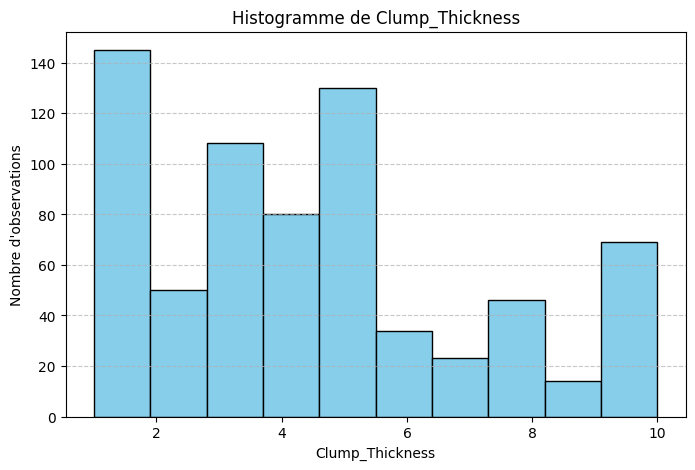

In [ ]:
# Histogramme de la variable Clump_Thickness
plt.figure(figsize=(8,5))
plt.hist(cancer['Clump_Thickness'], bins=10, color='skyblue', edgecolor='black')
plt.title("Histogramme de Clump_Thickness")
plt.xlabel("Clump_Thickness")
plt.ylabel("Nombre d'observations")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


<Axes: ylabel='Frequency'>

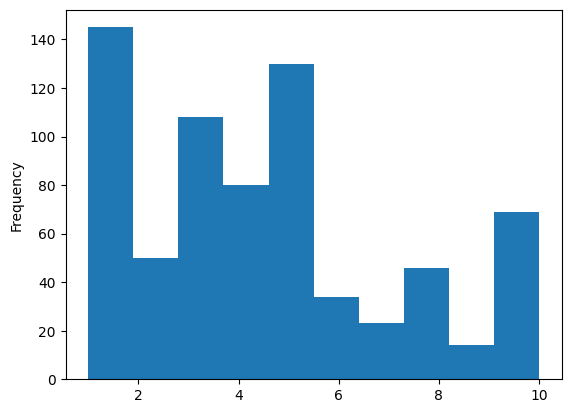

In [ ]:
cancer['Clump_Thickness'].plot.hist() #--version2 histo

(d) Utiliser la fonction `scatter()` pour afficher la variable `Cell_Size_Uniformity` en fonction de la variable `Cell_Shape_Uniformity` et étudier la corrélation des 2 variables

<Axes: xlabel='Cell_Size_Uniformity', ylabel='Cell_Shape_Uniformity'>

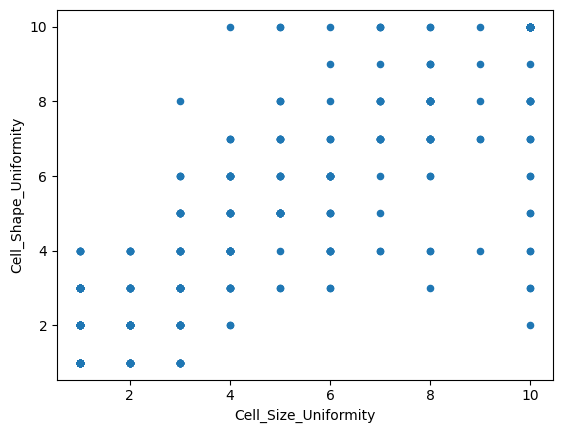

In [ ]:
cancer.plot.scatter(x='Cell_Size_Uniformity',y='Cell_Shape_Uniformity')

(e) A l’aide de la fonction `crosstab`, afficher la table de contingence des variables `Mitoses` et `class`

In [ ]:
Tab_Con= pd.crosstab(cancer['Mitoses'], cancer['Class'])
print(Tab_Con)

Class    benign  malignant
Mitoses                   
1           445        134
2             8         27
3             2         31
4             0         12
5             1          5
6             0          3
7             1          8
8             1          7
10            0         14
